## Домашнее задание: Обучение и визуализация xLSTM


In [1]:
# Подавление предупреждений
import warnings
for warn in [UserWarning, FutureWarning]: warnings.filterwarnings("ignore", category = warn)
# Импорт необходимых библиотек
import os
import math
import torch
import time
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import numpy as np
import polars as pl
import pandas as pd
import sklearn
import networkx as nx
import jupyterlab as jlab
import ipywidgets
import matplotlib as mpl
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

from torch import Tensor
from einops import rearrange
from typing import Tuple, Callable
from torch.autograd import Function

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.datasets import load_iris
from sklearn.preprocessing import MinMaxScaler
from mpl_toolkits.mplot3d import Axes3D

## 1. Обучить простую модель семейства xLSTM для обработки данных


In [4]:
class CausalConv1D(nn.Module):
    def __init__(self, in_channels, out_channels, kernel_size, dilation=1, **kwargs):
        super(CausalConv1D, self).__init__()
        self.padding = (kernel_size - 1) * dilation
        self.conv = nn.Conv1d(in_channels, out_channels, kernel_size, padding=self.padding, dilation=dilation, **kwargs)

    def forward(self, x):
        x = self.conv(x)
        return x[:, :, :-self.padding]

class BlockDiagonal(nn.Module):
    def __init__(self, in_features, out_features, num_blocks):
        super(BlockDiagonal, self).__init__()
        self.in_features = in_features
        self.out_features = out_features
        self.num_blocks = num_blocks

        assert out_features % num_blocks == 0
        
        block_out_features = out_features // num_blocks
        
        self.blocks = nn.ModuleList([
            nn.Linear(in_features, block_out_features)
            for _ in range(num_blocks)
        ])
        
    def forward(self, x):
        x = [block(x) for block in self.blocks]
        x = torch.cat(x, dim=-1)
        return x

class sLSTMBlock(nn.Module):
    def __init__(self, input_size, head_size, num_heads, proj_factor=4/3):
        super(sLSTMBlock, self).__init__()
        self.input_size = input_size
        self.head_size = head_size
        self.hidden_size = head_size * num_heads
        self.num_heads = num_heads
        self.proj_factor = proj_factor

        assert proj_factor > 0

        self.layer_norm = nn.LayerNorm(input_size)
        self.causal_conv = CausalConv1D(1, 1, 4)

        self.Wz = BlockDiagonal(input_size, self.hidden_size, num_heads)
        self.Wi = BlockDiagonal(input_size, self.hidden_size, num_heads)
        self.Wf = BlockDiagonal(input_size, self.hidden_size, num_heads)
        self.Wo = BlockDiagonal(input_size, self.hidden_size, num_heads)

        self.Rz = BlockDiagonal(self.hidden_size, self.hidden_size, num_heads)
        self.Ri = BlockDiagonal(self.hidden_size, self.hidden_size, num_heads)
        self.Rf = BlockDiagonal(self.hidden_size, self.hidden_size, num_heads)
        self.Ro = BlockDiagonal(self.hidden_size, self.hidden_size, num_heads)

        self.group_norm = nn.GroupNorm(num_heads, self.hidden_size)

        self.up_proj_left = nn.Linear(self.hidden_size, int(self.hidden_size * proj_factor))
        self.up_proj_right = nn.Linear(self.hidden_size, int(self.hidden_size * proj_factor))
        self.down_proj = nn.Linear(int(self.hidden_size * proj_factor), input_size)
        self.i_history = []
        self.f_history = []
        self.o_history = []

    def forward(self, x, prev_state):
        assert x.size(-1) == self.input_size
        self.i_history = []
        self.f_history = []
        self.o_history = []
        h_prev, c_prev, n_prev, m_prev = prev_state

        h_prev = h_prev.to(x.device)
        c_prev = c_prev.to(x.device)
        n_prev = n_prev.to(x.device)
        m_prev = m_prev.to(x.device)
        
        x_norm = self.layer_norm(x)
        x_conv = F.silu(self.causal_conv(x_norm.unsqueeze(1)).squeeze(1))

        z = torch.tanh(self.Wz(x_norm) + self.Rz(h_prev))
        o = torch.sigmoid(self.Wo(x_norm) + self.Ro(h_prev)) # вес
        i_tilde = self.Wi(x_conv) + self.Ri(h_prev)
        f_tilde = self.Wf(x_conv) + self.Rf(h_prev)

        m_t = torch.max(f_tilde + m_prev, i_tilde)
        i = torch.exp(i_tilde - m_t) # Всегда <= 1.0 # вес
        f = torch.exp(f_tilde + m_prev - m_t) # Всегда <= 1.0 # вес

        self.i_history.append(i.detach().cpu())
        self.f_history.append(f.detach().cpu())
        self.o_history.append(o.detach().cpu())

        c_t = f * c_prev + i * z
        n_t = f * n_prev + i
        h_t = o * c_t / n_t

        output = h_t
        output_norm = self.group_norm(output)
        output_left = self.up_proj_left(output_norm)
        output_right = self.up_proj_right(output_norm)
        output_gated = F.gelu(output_right)
        output = output_left * output_gated
        output = self.down_proj(output)
        final_output = output + x

        return final_output, (h_t, c_t, n_t, m_t)
    
class sLSTM(nn.Module):
    # Add bias, dropout, bidirectional
    def __init__(self, input_size, head_size, num_heads, num_layers=1, batch_first=False, proj_factor=4/3):
        super(sLSTM, self).__init__()
        self.input_size = input_size
        self.head_size = head_size
        self.hidden_size = head_size * num_heads
        self.num_heads = num_heads
        self.num_layers = num_layers
        self.batch_first = batch_first
        self.proj_factor_slstm = proj_factor

        self.layers = nn.ModuleList([sLSTMBlock(input_size, head_size, num_heads, proj_factor) for _ in range(num_layers)])

    def forward(self, x, state=None):
        assert x.ndim == 3
        if self.batch_first: x = x.transpose(0, 1)
        seq_len, batch_size, _ = x.size()
        
        if state is not None:
            state = torch.stack(list(state)).to(x.device)
            assert state.ndim == 4
            num_hidden, state_num_layers, state_batch_size, state_input_size = state.size()
            assert num_hidden == 4
            assert state_num_layers == self.num_layers
            assert state_batch_size == batch_size
            assert state_input_size == self.input_size
            state = state.transpose(0, 1)
        else:
            state = torch.zeros(self.num_layers, 4, batch_size, self.hidden_size, device=x.device)

        output = []
        for t in range(seq_len):
            x_t = x[t]
            for layer in range(self.num_layers):
                x_t, state_tuple = self.layers[layer](x_t, tuple(state[layer].clone()))
                state[layer] = torch.stack(list(state_tuple))
            output.append(x_t)
        
        output = torch.stack(output)
        if self.batch_first:
            output = output.transpose(0, 1)
        state = tuple(state.transpose(0, 1))
        return output, state

class mLSTMBlock(nn.Module):
    def __init__(self, input_size, head_size, num_heads, proj_factor=2):
        super(mLSTMBlock, self).__init__()
        self.input_size = input_size
        self.head_size = head_size
        self.hidden_size = head_size * num_heads
        self.num_heads = num_heads
        self.proj_factor = proj_factor

        assert proj_factor > 0

        self.layer_norm = nn.LayerNorm(input_size)
        self.up_proj_left = nn.Linear(input_size, int(input_size * proj_factor))
        self.up_proj_right = nn.Linear(input_size, self.hidden_size)
        self.down_proj = nn.Linear(self.hidden_size, input_size)

        self.causal_conv = CausalConv1D(1, 1, 4)
        self.skip_connection = nn.Linear(int(input_size * proj_factor), self.hidden_size)

        self.Wq = BlockDiagonal(int(input_size * proj_factor), self.hidden_size, num_heads)
        self.Wk = BlockDiagonal(int(input_size * proj_factor), self.hidden_size, num_heads)
        self.Wv = BlockDiagonal(int(input_size * proj_factor), self.hidden_size, num_heads)
        self.Wi = nn.Linear(int(input_size * proj_factor), self.hidden_size)
        self.Wf = nn.Linear(int(input_size * proj_factor), self.hidden_size)
        self.Wo = nn.Linear(int(input_size * proj_factor), self.hidden_size)

        self.group_norm = nn.GroupNorm(num_heads, self.hidden_size)

    def forward(self, x, prev_state):
        h_prev, c_prev, n_prev, m_prev = prev_state

        h_prev = h_prev.to(x.device)
        c_prev = c_prev.to(x.device)
        n_prev = n_prev.to(x.device)
        m_prev = m_prev.to(x.device)
        
        assert x.size(-1) == self.input_size
        x_norm = self.layer_norm(x)
        x_up_left = self.up_proj_left(x_norm)
        x_up_right = self.up_proj_right(x_norm)

        x_conv = F.silu(self.causal_conv(x_up_left.unsqueeze(1)).squeeze(1))
        x_skip = self.skip_connection(x_conv)

        q = self.Wq(x_conv)
        k = self.Wk(x_conv) / (self.head_size ** 0.5)
        v = self.Wv(x_up_left)

        i_tilde = self.Wi(x_conv)
        f_tilde = self.Wf(x_conv)
        o = torch.sigmoid(self.Wo(x_up_left))

        m_t = torch.max(f_tilde + m_prev, i_tilde)
        i = torch.exp(i_tilde - m_t)
        f = torch.exp(f_tilde + m_prev - m_t)

        c_t = f * c_prev + i * (v * k) # v @ k.T
        n_t = f * n_prev + i * k
        h_t = o * (c_t * q) / torch.max(torch.abs(n_t.T @ q), 1)[0] # o * (c @ q) / max{|n.T @ q|, 1}

        output = h_t
        output_norm = self.group_norm(output)
        output = output_norm + x_skip
        output = output * F.silu(x_up_right)
        output = self.down_proj(output)
        final_output = output + x

        return final_output, (h_t, c_t, n_t, m_t)
    
class mLSTM(nn.Module):
    # Add bias, dropout, bidirectional
    def __init__(self, input_size, head_size, num_heads, num_layers=1, batch_first=False, proj_factor=2):
        super(mLSTM, self).__init__()
        self.input_size = input_size
        self.head_size = head_size
        self.hidden_size = head_size * num_heads
        self.num_heads = num_heads
        self.num_layers = num_layers
        self.batch_first = batch_first
        self.proj_factor_slstm = proj_factor

        self.layers = nn.ModuleList([mLSTMBlock(input_size, head_size, num_heads, proj_factor) for _ in range(num_layers)])

    def forward(self, x, state=None):
        assert x.ndim == 3
        if self.batch_first: x = x.transpose(0, 1)
        seq_len, batch_size, _ = x.size()
        
        if state is not None:
            state = torch.stack(list(state)).to(x.device)
            assert state.ndim == 4
            num_hidden, state_num_layers, state_batch_size, state_input_size = state.size()
            assert num_hidden == 4
            assert state_num_layers == self.num_layers
            assert state_batch_size == batch_size
            assert state_input_size == self.input_size
            state = state.transpose(0, 1)
        else:
            state = torch.zeros(self.num_layers, 4, batch_size, self.hidden_size, device=x.device)

        output = []
        for t in range(seq_len):
            x_t = x[t]
            for layer in range(self.num_layers):
                x_t, state_tuple = self.layers[layer](x_t, tuple(state[layer].clone()))
                state[layer] = torch.stack(list(state_tuple))
            output.append(x_t)
        
        output = torch.stack(output)
        if self.batch_first:
            output = output.transpose(0, 1)
        state = tuple(state.transpose(0, 1))
        return output, state

class xLSTM(nn.Module):
    # Add bias, dropout, bidirectional
    def __init__(self, input_size, head_size, num_heads, layers, batch_first=False, proj_factor_slstm=4/3, proj_factor_mlstm=2):
        super(xLSTM, self).__init__()
        self.input_size = input_size
        self.head_size = head_size
        self.hidden_size = head_size * num_heads
        self.num_heads = num_heads
        self.layers = layers
        self.num_layers = len(layers)
        self.batch_first = batch_first
        self.proj_factor_slstm = proj_factor_slstm
        self.proj_factor_mlstm = proj_factor_mlstm

        self.layers = nn.ModuleList()
        for layer_type in layers:
            if layer_type == 's':
                layer = sLSTMBlock(input_size, head_size, num_heads, proj_factor_slstm)
            elif layer_type == 'm':
                layer = mLSTMBlock(input_size, head_size, num_heads, proj_factor_mlstm)
            else:
                raise ValueError(f"Invalid layer type")
            self.layers.append(layer)

    def forward(self, x, state=None):
        assert x.ndim == 3
        if self.batch_first: x = x.transpose(0, 1)
        seq_len, batch_size, _ = x.size()
        
        if state is not None:
            state = torch.stack(list(state)).to(x.device)
            assert state.ndim == 4
            num_hidden, state_num_layers, state_batch_size, state_input_size = state.size()
            assert num_hidden == 4
            assert state_num_layers == self.num_layers
            assert state_batch_size == batch_size
            assert state_input_size == self.input_size
            state = state.transpose(0, 1)
        else:
            state = torch.zeros(self.num_layers, 4, batch_size, self.hidden_size, device=x.device)

        output = []
        for t in range(seq_len):
            x_t = x[t]
            for layer in range(self.num_layers):
                x_t, state_tuple = self.layers[layer](x_t, tuple(state[layer].clone()))
                state[layer] = torch.stack(list(state_tuple))
            output.append(x_t)
        
        output = torch.stack(output)
        if self.batch_first:
            output = output.transpose(0, 1)
        state = tuple(state.transpose(0, 1))
        return output, state

### Обучение
Обучим на реальных данных: сведения о погоде за последние 10 лет в 12 разных городах. Возьмем данные только из 1 города, иначе модель обучается очень долго: 

In [ ]:
csv_path = "C:/Users/lbask/Downloads/global_weather_100_cities_2014_2024.csv"
df = pd.read_csv(csv_path)

df["date"] = pd.to_datetime(df["date"])

features = ["avg_temperature_c", "avg_humidity_pct", "rainfall_mm", "max_wind_speed_kmh"]

scaler = StandardScaler()
df[features] = scaler.fit_transform(df[features])

cities = df["city"].unique()
cities=cities[:1]

In [6]:
seq_len = 31
X = []
y = []

for city in cities:
    city_df = df[df["city"] == city]
    city_df = city_df.sort_values("date")
    data = city_df[features].values

    for i in range(len(data) - seq_len):
        input_seq = data[i:i+seq_len]
        target_seq = data[i+1:i+seq_len+1]
        X.append(input_seq)
        y.append(target_seq)
X=X[:128]
y=y[:128]
X = torch.tensor(np.array(X), dtype=torch.float32)
y = torch.tensor(np.array(y), dtype=torch.float32)

print("X shape:", X.shape)
print("Y shape:", y.shape)

X shape: torch.Size([128, 31, 4])
Y shape: torch.Size([128, 31, 4])


In [26]:
model = xLSTM(input_size=4, head_size=16, num_heads=2, layers="msm")
criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=1e-3)
losses_xlstm=[]
input_tensor = X
target_tensor = y
start_time_x = time.time()
print(input_tensor.shape)
print(target_tensor.shape)

num_epochs = 20

for epoch in range(num_epochs):
    model.train()
    optimizer.zero_grad()
    output = model(input_tensor)

    if isinstance(output, tuple):
        output = output[0]

    loss = criterion(output, target_tensor)
    loss.backward()
    optimizer.step()
    losses_xlstm.append(loss.item())
    print(f"Epoch {epoch+1}/{num_epochs}, " f"Loss: {loss.item():.6f}")
training_time = time.time() - start_time_x
model.eval()

with torch.no_grad():
    output = model(input_tensor)
    gate_i = torch.stack(model.layers[1].i_history)
    gate_o = torch.stack(model.layers[1].o_history)
    gate_f = torch.stack(model.layers[1].f_history)

    if isinstance(output, tuple):
        output = output[0]
    print("Output shape after training:", output.shape)

torch.Size([128, 31, 4])
torch.Size([128, 31, 4])
Epoch 1/20, Loss: 0.399008
Epoch 2/20, Loss: 0.384392
Epoch 3/20, Loss: 0.373516
Epoch 4/20, Loss: 0.364047
Epoch 5/20, Loss: 0.355347
Epoch 6/20, Loss: 0.348272
Epoch 7/20, Loss: 0.342057
Epoch 8/20, Loss: 0.336292
Epoch 9/20, Loss: 0.330837
Epoch 10/20, Loss: 0.325978
Epoch 11/20, Loss: 0.321874
Epoch 12/20, Loss: 0.318337
Epoch 13/20, Loss: 0.315106
Epoch 14/20, Loss: 0.312095
Epoch 15/20, Loss: 0.309189
Epoch 16/20, Loss: 0.306823
Epoch 17/20, Loss: 0.304022
Epoch 18/20, Loss: 0.301653
Epoch 19/20, Loss: 0.299303
Epoch 20/20, Loss: 0.296994
Output shape after training: torch.Size([128, 31, 4])


## 2. Визуализировать веса внимания и интерпретировать их

Визуализируем веса внимания: 

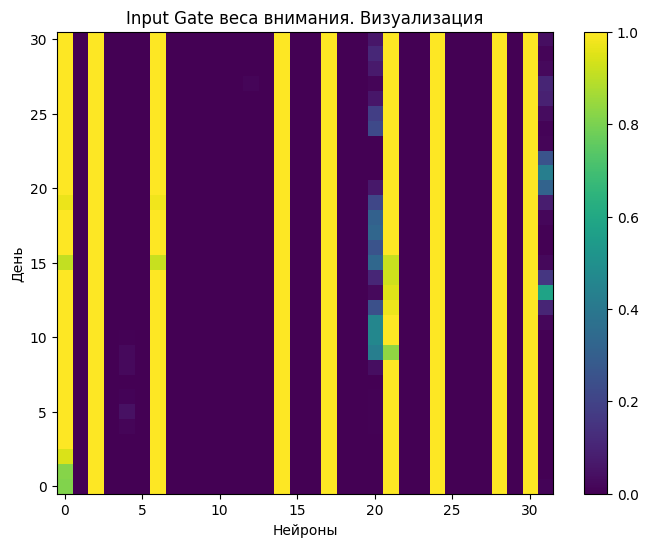

(31, 32)

In [34]:
sample = gate_i[0, :, :].numpy()
plt.figure(figsize=(8, 6))

plt.imshow(
    sample,
    aspect='auto',
    origin='lower'
)

plt.colorbar()
plt.title("Input Gate веса внимания. Визуализация")
plt.xlabel("Нейроны")
plt.ylabel("День")
plt.show()
sample.shape

#### _Интерпретация_: 

На графике `Input Gate` наблюдаются как полностью активные, так и полностью или практически неактивные нейроны. Несколько нейронов остаются открытыми почти на всей последовательности, что говорит об их постоянном участии в обновлении состояния памяти, а некоторые нейроны активируются лишь на отдельных временных шагах, что свидетельствует о выборочной записи информации в память модели. 

На графике это наглядно видно: есть полностью жёлтые столбцы, есть полностью фиолетовые, есть смешанные. То есть действительно разные нейроны выполняют разные функции.

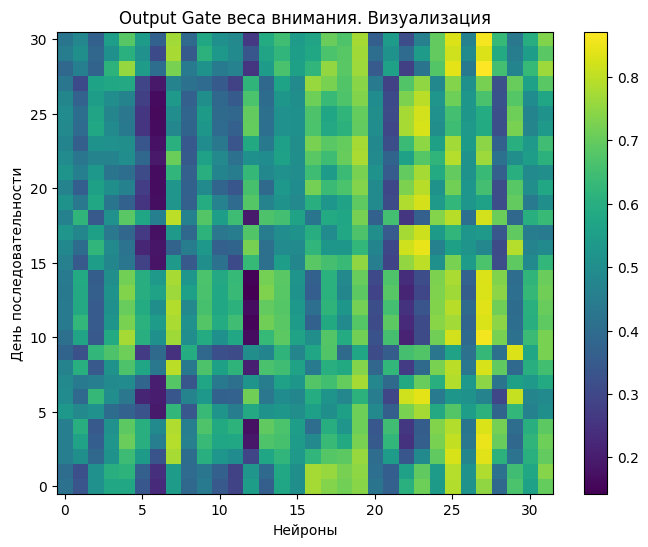

(31, 32)

In [ ]:
sample = gate_o[0, :, :].numpy()
plt.figure(figsize=(8, 6))

plt.imshow(
    sample,
    aspect='auto',
    origin='lower'
)

plt.colorbar()
plt.title("Output Gate веса внимания. Визуализация")
plt.xlabel("Нейроны")
plt.ylabel("День последовательности")
plt.show()
sample.shape

#### _Интерпретация_: 

На графике `Output Gate` более равномерное распределение значений по сравнению с `Input Gate`. Большинство нейронов имеют средний уровень активации, что говорит о плавном регулировании информации, передаваемой из внутреннего состояния памяти на выход модели.

Как это отображается визуально: нет большого количества полностью закрытых или полностью открытых ворот, значения распределены относительно равномерно, большинство клеток зеленые-голубые.

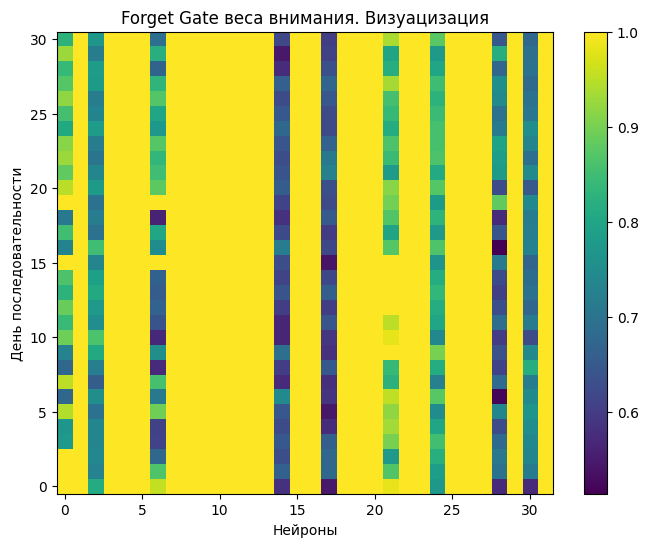

(31, 32)

In [ ]:
sample = gate_f[0, :, :].numpy()
plt.figure(figsize=(8, 6))

plt.imshow(
    sample,
    aspect='auto',
    origin='lower'
)

plt.colorbar()
plt.title("Forget Gate веса внимания. Визуацизация")
plt.xlabel("Нейроны")
plt.ylabel("День последовательности")
plt.show()
sample.shape

#### _Интерпретация_: 

На графике `Forget Gate` видно, что большинство нейронов имеют высокие значения коэффициента забывания, что свидетельствует о сохранении информации в памяти модели на протяжении значительной части временной последовательности. Это может быть связано с тем, что погодные данные обладают очевидной временной зависимостью, поэтому модели выгодно сохранять информацию о предыдущих днях при формировании прогноза. Но при этом есть и нейроны с относительно низким коэффициентом, что может говорить о том, что модель использует как долгосрочное хранение информации, так и механизм её выборочного обновления.


## 3. Сделать выводы о том, как модель воспринимает данные и принимает решения?

Чтобы решить 3 задание, обучим обычную `LSTM модель` на тех же данных и сравним: 

In [21]:
class WeatherLSTM(nn.Module):
    def __init__(self, input_size=4, hidden_size=32, num_layers=3):
        super().__init__()
        self.hidden_size = hidden_size
        self.num_layers = num_layers

        self.lstm = nn.LSTM(
            input_size=input_size,
            hidden_size=hidden_size,
            num_layers=num_layers,
            batch_first=True
        )

        self.fc = nn.Linear(hidden_size, input_size)

    def forward(self, x):
        h0 = torch.zeros(self.num_layers, x.size(0), self.hidden_size, device=x.device)
        c0 = torch.zeros(self.num_layers, x.size(0), self.hidden_size, device=x.device)
        out, _ = self.lstm(x, (h0, c0))
        out = self.fc(out)

        return out

In [29]:
model1 = WeatherLSTM(input_size=4, hidden_size=32, num_layers=3)
criterion = nn.MSELoss()
optimizer = optim.Adam(model1.parameters(), lr=1e-3)
losses_lstm=[]
input_tensor = X
target_tensor = y
start_time = time.time()
print(input_tensor.shape)
print(target_tensor.shape)

num_epochs = 20

for epoch in range(num_epochs):
    model1.train()
    optimizer.zero_grad()
    output = model1(input_tensor)

    if isinstance(output, tuple):
        output = output[0]

    loss = criterion(output, target_tensor)
    loss.backward()
    optimizer.step()
    losses_lstm.append(loss.item())
    print(f"Epoch {epoch+1}/{num_epochs}, " f"Loss: {loss.item():.6f}")
training_time1 = time.time() - start_time



torch.Size([128, 31, 4])
torch.Size([128, 31, 4])
Epoch 1/20, Loss: 0.461807
Epoch 2/20, Loss: 0.457619
Epoch 3/20, Loss: 0.453550
Epoch 4/20, Loss: 0.449586
Epoch 5/20, Loss: 0.445710
Epoch 6/20, Loss: 0.441911
Epoch 7/20, Loss: 0.438179
Epoch 8/20, Loss: 0.434506
Epoch 9/20, Loss: 0.430888
Epoch 10/20, Loss: 0.427319
Epoch 11/20, Loss: 0.423802
Epoch 12/20, Loss: 0.420342
Epoch 13/20, Loss: 0.416953
Epoch 14/20, Loss: 0.413658
Epoch 15/20, Loss: 0.410498
Epoch 16/20, Loss: 0.407533
Epoch 17/20, Loss: 0.404844
Epoch 18/20, Loss: 0.402535
Epoch 19/20, Loss: 0.400711
Epoch 20/20, Loss: 0.399438


In [ ]:
def count_parameters(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)

xlstm_params = count_parameters(model)
lstm_params = count_parameters(model1)

print("xLSTM params:", xlstm_params)
print("LSTM params:", lstm_params)



xLSTM params: 12735
LSTM params: 21892


In [32]:
print("Сравнение моделей:")

print(f"xLSTM loss: {losses_xlstm[-1]:.6f}")
print(f"LSTM loss:  {losses_lstm[-1]:.6f}")


print(f"xLSTM time: {training_time:.2f} секунд")
print(f"LSTM time:  {training_time1:.2f} секунд")

print(f"xLSTM params: {xlstm_params}")
print(f"LSTM params:  {lstm_params}")

Сравнение моделей:
xLSTM loss: 0.296994
LSTM loss:  0.399438
xLSTM time: 40.83 секунд
LSTM time:  4.26 секунд
xLSTM params: 12735
LSTM params:  21892


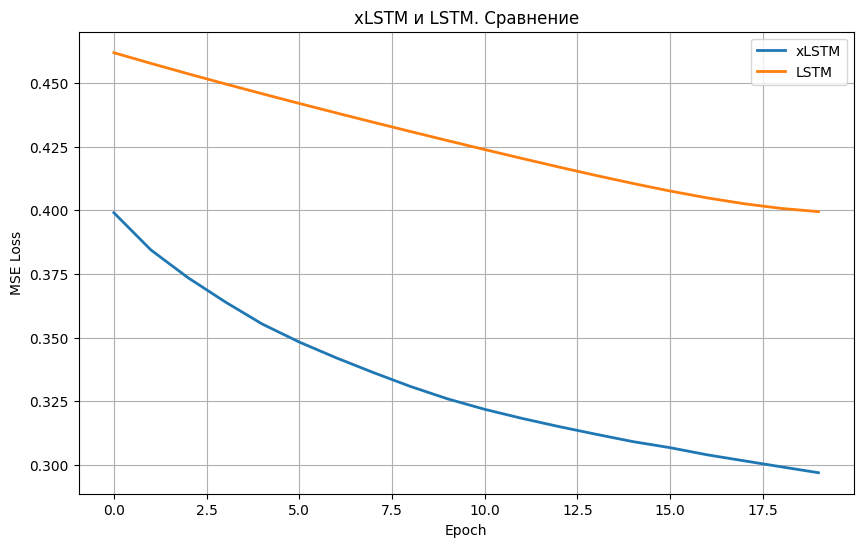

In [33]:
plt.figure(figsize=(10,6))

plt.plot(losses_xlstm, label="xLSTM", linewidth=2)
plt.plot(losses_lstm, label="LSTM", linewidth=2)

plt.xlabel("Epoch")
plt.ylabel("MSE Loss")
plt.title("xLSTM и LSTM. Сравнение")
plt.legend()
plt.grid(True)

plt.show()

### Вывод к _Заданию 3_


Для оценки эффективности архитектуры xLSTM было проведено сравнение с классической LSTM на одном и том же наборе данных.

Полученные результаты показывают, что модель `xLSTM` обеспечила более высокую точность прогнозирования. Значение функции потерь оказалось ниже приблизительно на $25.6\%$ по сравнению с классической `LSTM`. При этом `xLSTM` содержит меньшее количество обучаемых параметров, однако требует значительно большего времени обучения. Это связано с более сложной внутренней структурой блоков `sLSTM` и `mLSTM`, а также дополнительными вычислениями, связанными с механизмами управления памятью.

График изменения функции потерь также показывает, что `xLSTM` обучается стабильнее и достигает меньшего итогового значения ошибки по сравнению с классической `LSTM`.
Таким образом, для рассматриваемой задачи прогнозирования погоды `xLSTM` продемонстрировала более качественные результаты и более точное предсказание при меньшем количестве параметров. Однако стоит отметить, что при значительном увеличении размера набора данных, время обучения также значительно увеличится, что делает классическую `LSTM` в таких случаях более предпочтительной.
